# Aufgabe 0
Für unseren Versuch ist eine Theoretische Grundlage notwendig, die versucht wir in diesem Kapitell zu erlangen.

Im Frauenhofer-Grenzfall ist das Beugungsmuster $I(k)$ proportional zum Betrag der Fourier-Transformierten, der Öffnungsfunktion $f(x)$. Diese sind für einen {#einen-spalt} und für zwei Spalten {#zwei-spalten} folgendermaßen definert.
$$f_1(x) = \text{rect}\left(\frac{x}{a}\right)$${#einen-spalt}
$$f_2(x) = \text{rect}\left(\frac{x+d/2}{a}\right) + \text{rect}\left(\frac{x-d/2}{a}\right)$${#zwei-spalten}
Dabei sind für die Öffnungsfunktionen, die FOurier-Transformierten, die folgenden
$$F_1(k) = a ~ \text{sinc}(ka)$$
$$F_2(k) = 2a ~ \text{sinc}(ka) ~ \text{cos}(kd/2)$$
Nach der Beziehung $I(k) = |F(k)|²$, erhalten wir folgendes Fauenhofer-Beugungsmuster, welches das Intensitätspril ist.

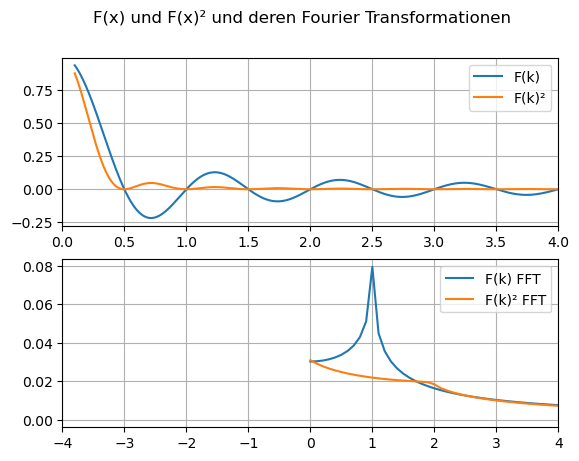

In [24]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

# Number of sample points

N = 10000

# sample spacing

T = 1 / 1000

def F(k): #Fraunhofer-Beugungsmuster eines Einzelspalts
    return np.sin(2 * np.pi * k)/(2 * np.pi * k)

x = np.linspace(0.1, N*T, N, endpoint=False)
y = F(x)
y_squared = y**2 # Intensität, da I ~ |F|²

yf = fft(y) # Spaltfunktion im Ortraum (numerische FFT)
yf_squared = fft(y_squared) # FFT des Intensitätsmuster -> Faltung im Ortsraum
# damit ds Flatungstheorem erklähren

xf = fftfreq(N, T)[:N//2]

fig, axs = plt.subplots(2)
fig.suptitle("F(x) und F(x)² und deren Fourier Transformationen")

axs[0].plot(x, y, label="F(k)")
axs[0].plot(x, y_squared, label="F(k)²")
axs[0].set_xlim(0, 4)
axs[0].grid()
axs[0].legend()


axs[1].plot(xf, (2.0/N * np.abs(yf[0:N//2])), label="F(k) FFT")
axs[1].plot(xf, (2.0/N * np.abs(yf_squared[0:N//2])), label="F(k)² FFT")
axs[1].set_xlim(-4, 4)
axs[1].grid()
axs[1].legend()
plt.show()

## Diskussion unter berücksichtigung des Faltungstheorems

$$FT[f(x) \ \otimes g(x) ] = FT \left[ \int_{- \infty}^{\infty}f(x')g(x-x')dx'\right] = FT[f(x)]FT[g(x)]=F(k)G(k)$$

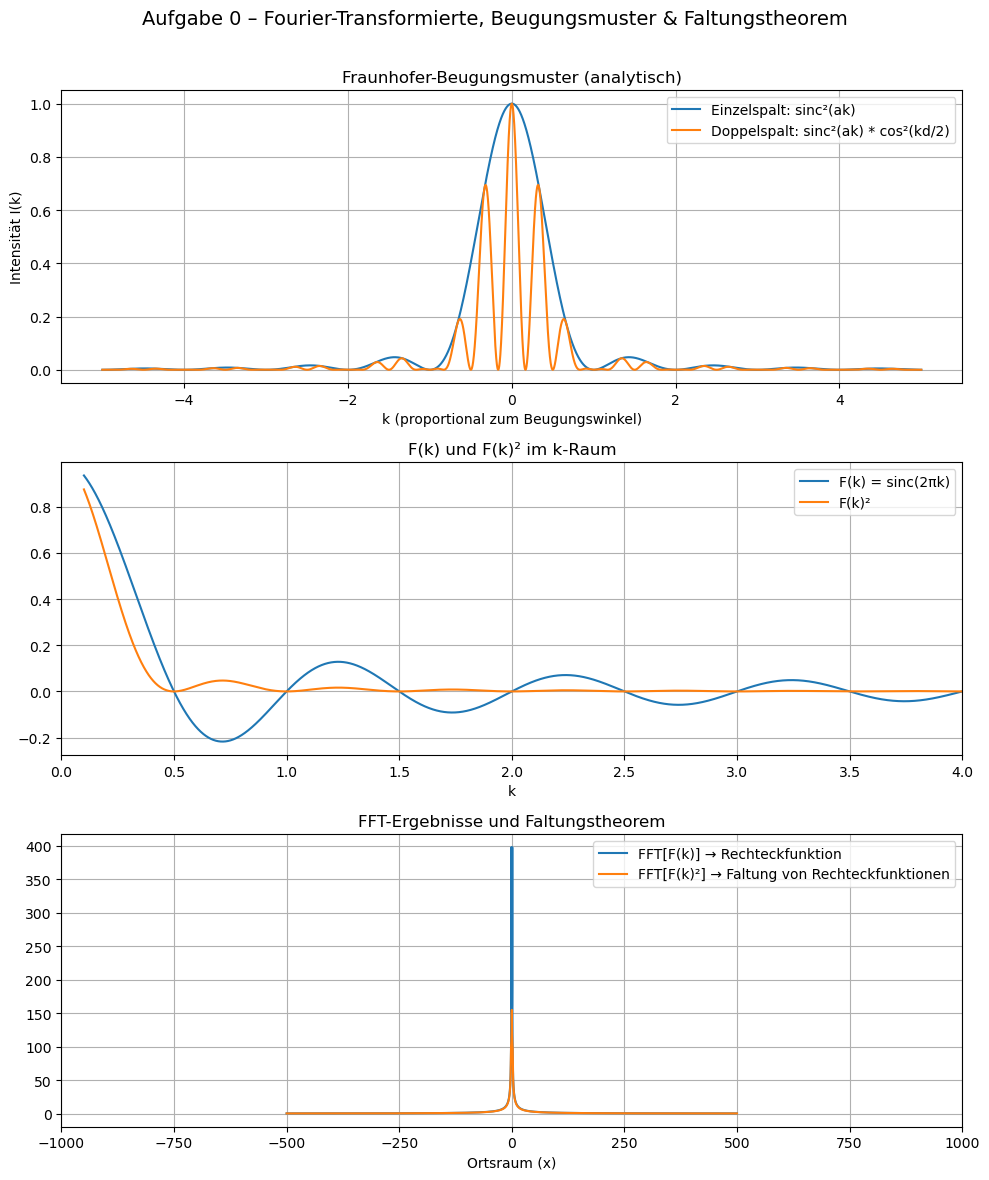

In [23]:
import numpy as np
from scipy.fft import fft, fftfreq, fftshift, ifft
import matplotlib.pyplot as plt

# ============================================================
# 1️⃣ Grundparameter
# ============================================================
N = 10000          # Anzahl der Stützstellen
T = 1 / 1000       # Abtastintervall
k = np.linspace(-5, 5, N)  # "Frequenzraum" (k)

# ============================================================
# 2️⃣ Definition der Funktionen
# ============================================================

# Einzelspalt (Fraunhofer-Beugungsmuster)
def F_single(k, a=1.0):
    # sinc(x) = sin(pi*x)/(pi*x) in numpy -> np.sinc(x)
    return np.sinc(a * k)

# Doppelspalt (zwei Spalte mit Abstand d)
def F_double(k, a=1.0, d=3.0):
    return np.sinc(a * k) * np.cos(np.pi * d * k)

# ============================================================
# 3️⃣ Berechnung der Intensitätsverteilungen
# ============================================================
I_single = F_single(k)**2
I_double = F_double(k)**2

# ============================================================
# 4️⃣ FFT-Teil (numerischer Vergleich)
# ============================================================
# Aufgabe: Fourier-Transformierte von F(k) und F(k)^2

def F_func(k):
    return np.sin(2 * np.pi * k) / (2 * np.pi * k)

x = np.linspace(0.1, N*T, N, endpoint=False)
y = F_func(x)
y_squared = y**2

# FFT berechnen
Y_fft = fft(y)
Y_fft_squared = fft(y_squared)
xf = fftfreq(N, T)
xf_shifted = fftshift(xf)
Y_fft_shifted = fftshift(np.abs(Y_fft))
Y_fft_squared_shifted = fftshift(np.abs(Y_fft_squared))

# ============================================================
# 5️⃣ Plot-Ergebnisse
# ============================================================

fig, axs = plt.subplots(3, 1, figsize=(10, 12))
fig.suptitle("Aufgabe 0 – Fourier-Transformierte, Beugungsmuster & Faltungstheorem", fontsize=14)

# --- (1) Analytisch: Einzel- und Doppelspalt Fraunhofer-Muster ---
axs[0].plot(k, I_single, label="Einzelspalt: sinc²(ak)")
axs[0].plot(k, I_double, label="Doppelspalt: sinc²(ak) * cos²(kd/2)")
axs[0].set_title("Fraunhofer-Beugungsmuster (analytisch)")
axs[0].set_xlabel("k (proportional zum Beugungswinkel)")
axs[0].set_ylabel("Intensität I(k)")
axs[0].legend()
axs[0].grid()

# --- (2) Numerisch: F(k) und F(k)² ---
axs[1].plot(x, y, label="F(k) = sinc(2πk)")
axs[1].plot(x, y_squared, label="F(k)²")
axs[1].set_xlim(0, 4)
axs[1].set_title("F(k) und F(k)² im k-Raum")
axs[1].set_xlabel("k")
axs[1].legend()
axs[1].grid()

# --- (3) FFT: zeigt Faltungstheorem ---
axs[2].plot(xf_shifted, Y_fft_shifted, label="FFT[F(k)] → Rechteckfunktion")
axs[2].plot(xf_shifted, Y_fft_squared_shifted, label="FFT[F(k)²] → Faltung von Rechteckfunktionen")
axs[2].set_xlim(-1000, 1000)
axs[2].set_title("FFT-Ergebnisse und Faltungstheorem")
axs[2].set_xlabel("Ortsraum (x)")
axs[2].legend()
axs[2].grid()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
